# 06 — Policy Recommendation

## Goals
- Translate causal findings into actionable inventory policy recommendations
- Build a cost-benefit framework per product segment
- Identify optimal safety stock multiplier per segment
- Prioritize which products to target first given a budget constraint
- Summarize findings for a non-technical stakeholder audience

## From Causal Finding to Policy Decision
The causal analysis answered: *does the policy work?*
This notebook answers: *should we implement it, for which products, and at what level?*

## Framework
For each product segment:
1. Compute stockout cost avoided by treatment
2. Compute holding cost increase from treatment
3. Compute net benefit = stockout cost avoided - holding cost increase
4. Find the multiplier that maximizes net benefit
5. Rank products by cost-benefit ratio for budget-constrained rollout

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
PARQUET_PATH = Path('../data/parquet')
REPORTS_PATH = Path('../reports')

# Load experiment dataset and simulation results
exp_df     = pd.read_parquet(PARQUET_PATH / 'experiment_dataset.parquet')
results_df = pd.read_parquet(PARQUET_PATH / 'simulation_results.parquet')

# Load simulation results for multiple multipliers
# We need to test 1.1x, 1.2x, 1.3x, 1.4x, 1.5x, 2.0x
print("Data loaded.")
print(f"Experiment dataset: {exp_df.shape}")
print(f"Simulation results: {results_df.shape}")
print(f"\nSegments: {exp_df['segment'].unique()}")
print(f"Policies: {results_df['policy'].unique()}")

Data loaded.
Experiment dataset: (5667, 26)
Simulation results: (11334, 15)

Segments: ['slow' 'dead_slow' 'fast' 'medium']
Policies: ['baseline' 'treatment']


In [5]:
import numpy as np

def simulate_inventory(demand_series, forecast_series, safety_stock_multiplier,
                       lead_time, order_quantity, reorder_point, hc_rate, p99_demand):
    n_days = len(demand_series)
    adjusted_reorder = reorder_point * safety_stock_multiplier
    inventory = adjusted_reorder + order_quantity
    pending_orders = {}
    stockout_days = 0
    units_lost    = 0
    total_holding = 0.0
    units_sold    = 0

    for day in range(n_days):
        if day in pending_orders:
            inventory += pending_orders.pop(day)
        demand = min(float(demand_series[day]), p99_demand)
        demand = max(0, demand)
        if demand <= inventory:
            inventory -= demand
            units_sold += demand
        else:
            units_sold    += inventory
            units_lost    += demand - inventory
            inventory      = 0
            stockout_days += 1
        total_holding += inventory * hc_rate
        if inventory <= adjusted_reorder and day not in [
            v for v in range(day, day + lead_time) if v in pending_orders
        ]:
            pending_orders[day + lead_time] = order_quantity

    total_demand = units_sold + units_lost
    return {
        'stockout_days':      stockout_days,
        'stockout_rate':      stockout_days / n_days if n_days > 0 else 0,
        'units_lost':         units_lost,
        'units_sold':         units_sold,
        'fill_rate':          units_sold / total_demand if total_demand > 0 else 1.0,
        'total_holding_cost': total_holding,
        'avg_holding_cost':   total_holding / n_days if n_days > 0 else 0,
        'n_days':             n_days
    }

# Load forecasts and product params
forecasts = pd.read_parquet(PARQUET_PATH / 'demand_forecasts_v2.parquet')
forecasts['date'] = pd.to_datetime(forecasts['date'])

product_params = results_df[results_df['policy']=='baseline'][[
    'item_id', 'store_id', 'segment', 'mean_demand',
    'order_quantity', 'reorder_point'
]].copy()

p99 = forecasts.groupby(['item_id','store_id'])['units_sold'].quantile(0.99).reset_index()
p99.columns = ['item_id', 'store_id', 'p99_demand']
product_params = product_params.merge(p99, on=['item_id','store_id'], how='left')

LEAD_TIME = 7
HC_RATE   = 0.01

print(f"Product params shape: {product_params.shape}")
print(f"Sample:")
print(product_params.head(3).to_string())

Product params shape: (5667, 7)
Sample:
   item_id  store_id segment  mean_demand  order_quantity  reorder_point  p99_demand
0        0         0    slow     0.696217             1.0            6.0         4.0
1        0         1    slow     0.930260             1.0            8.0         7.0
2        0         2    slow     0.989362             1.0            8.0        13.0


In [7]:
# Run simulation across multiple safety stock multipliers
from tqdm import tqdm

MULTIPLIERS = [1.0, 1.1, 1.2, 1.3, 1.5, 2.0, 3.0]
STOCKOUT_COST_PER_UNIT = 5.0  # assumed lost margin per unit not sold

multi_results = []

print("Running multi-multiplier simulation...")
for multiplier in MULTIPLIERS:
    print(f"  Multiplier: {multiplier}x")
    for _, params in product_params.iterrows():
        mask = (
            (forecasts['item_id'] == params['item_id']) &
            (forecasts['store_id'] == params['store_id'])
        )
        product_data = forecasts[mask].sort_values('date')
        if len(product_data) < 30:
            continue

        outcome = simulate_inventory(
            demand_series           = product_data['units_sold'].values,
            forecast_series         = product_data['demand_forecast'].values,
            safety_stock_multiplier = multiplier,
            lead_time               = LEAD_TIME,
            order_quantity          = int(params['order_quantity']),
            reorder_point           = float(params['reorder_point']),
            hc_rate                 = HC_RATE,
            p99_demand              = float(params['p99_demand'])
        )

        multi_results.append({
            'item_id':     params['item_id'],
            'store_id':    params['store_id'],
            'segment':     params['segment'],
            'mean_demand': params['mean_demand'],
            'multiplier':  multiplier,
            **outcome
        })

multi_df = pd.DataFrame(multi_results)
multi_df.to_parquet(PARQUET_PATH / 'multi_multiplier_results.parquet', index=False)

print(f"\nDone — {len(multi_df):,} results")
print(f"Shape: {multi_df.shape}")

Running multi-multiplier simulation...
  Multiplier: 1.0x
  Multiplier: 1.1x
  Multiplier: 1.2x
  Multiplier: 1.3x
  Multiplier: 1.5x
  Multiplier: 2.0x
  Multiplier: 3.0x

Done — 39,669 results
Shape: (39669, 13)


In [8]:
# Cost-benefit analysis per segment per multiplier
STOCKOUT_COST_PER_UNIT = 5.0  # assumed lost margin per unit not sold

# Get baseline metrics per product
baseline_metrics = multi_df[multi_df['multiplier'] == 1.0][[
    'item_id', 'store_id', 'avg_holding_cost', 'units_lost', 'stockout_rate'
]].rename(columns={
    'avg_holding_cost': 'base_hc',
    'units_lost':       'base_units_lost',
    'stockout_rate':    'base_stockout_rate'
})

# Merge baseline into full results
multi_df = multi_df.merge(baseline_metrics, on=['item_id', 'store_id'], how='left')

# Compute costs
multi_df['hc_increase']        = multi_df['avg_holding_cost'] - multi_df['base_hc']
multi_df['stockout_cost_saved'] = (multi_df['base_units_lost'] - multi_df['units_lost']) * STOCKOUT_COST_PER_UNIT
multi_df['net_benefit']        = multi_df['stockout_cost_saved'] - multi_df['hc_increase'] * multi_df['n_days']

# Segment-level cost benefit by multiplier
seg_cb = multi_df.groupby(['segment', 'multiplier'], observed=True).agg(
    stockout_rate      = ('stockout_rate', 'mean'),
    hc_increase        = ('hc_increase', 'mean'),
    stockout_cost_saved = ('stockout_cost_saved', 'mean'),
    net_benefit        = ('net_benefit', 'mean')
).reset_index()

print("Cost-benefit by segment and multiplier:")
print(seg_cb.to_string(index=False))

Cost-benefit by segment and multiplier:
  segment  multiplier  stockout_rate  hc_increase  stockout_cost_saved  net_benefit
dead_slow         1.0       0.021217     0.000000             0.000000     0.000000
dead_slow         1.1       0.021498     0.000572            -0.086288    -0.570395
dead_slow         1.2       0.021292     0.001483             2.677258     1.422680
dead_slow         1.3       0.018419     0.005034            19.995151    15.735990
dead_slow         1.5       0.013313     0.012880            48.637793    37.740932
dead_slow         2.0       0.008405     0.028152            77.330268    53.514024
dead_slow         3.0       0.005256     0.057778            97.025084    48.144855
     fast         1.0       0.186199     0.000000             0.000000     0.000000
     fast         1.1       0.180182     0.063266           332.952797   279.429976
     fast         1.2       0.175181     0.129117           592.835664   483.602318
     fast         1.3       0.171089

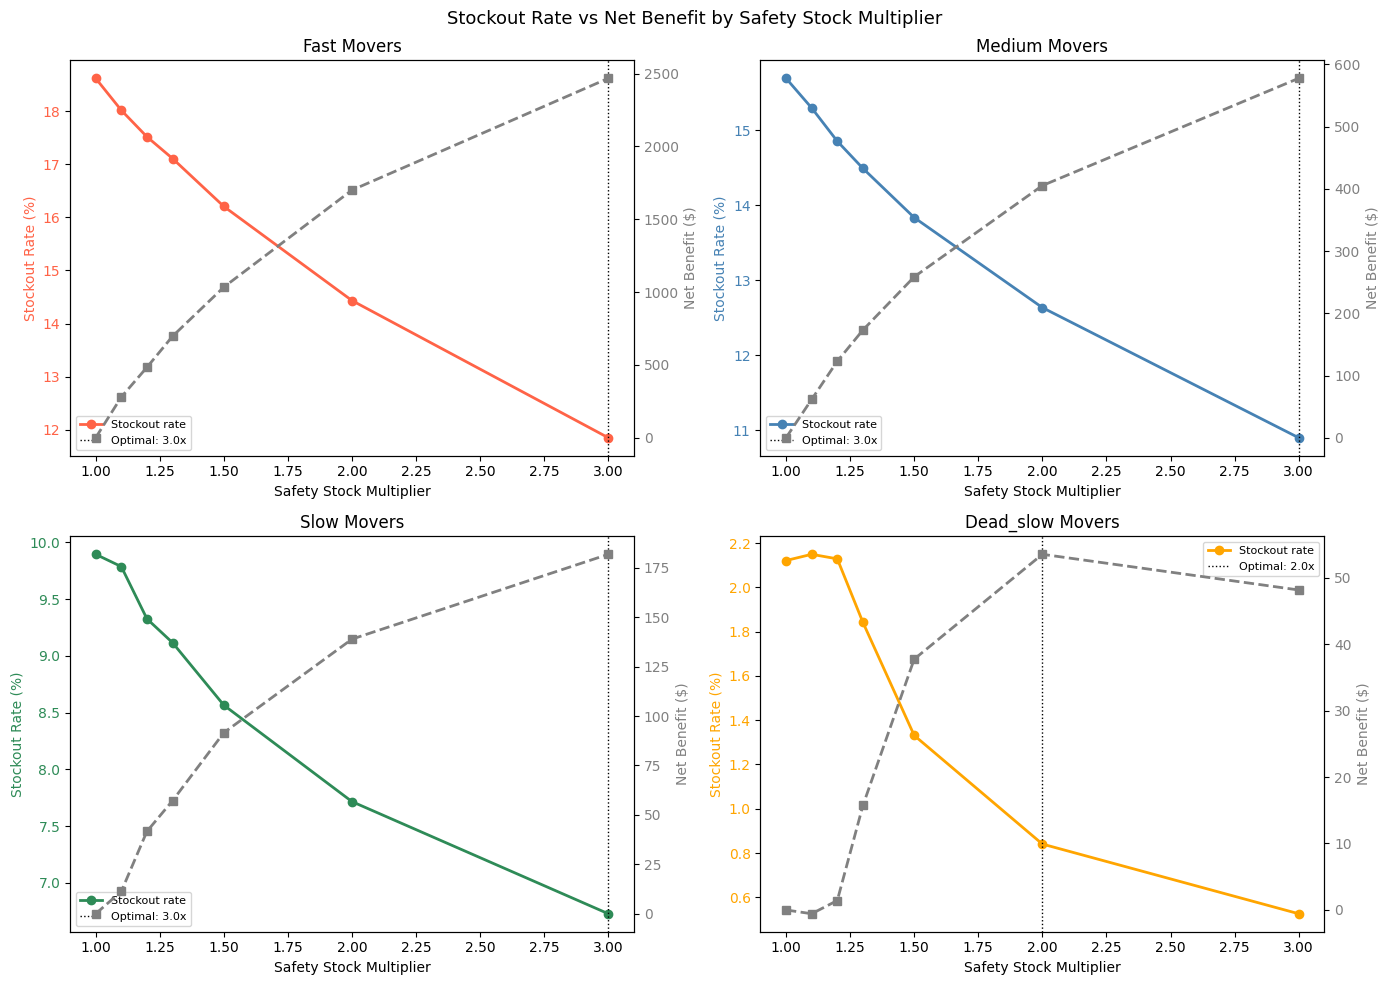

Optimal safety stock multiplier per segment:
  fast         optimal: 3.0x  net benefit: $2468.10  stockout rate: 11.85%
  medium       optimal: 3.0x  net benefit: $577.60  stockout rate: 10.90%
  slow         optimal: 3.0x  net benefit: $181.80  stockout rate: 6.73%
  dead_slow    optimal: 2.0x  net benefit: $53.51  stockout rate: 0.84%


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

segments = ['fast', 'medium', 'slow', 'dead_slow']
colors   = ['tomato', 'steelblue', 'seagreen', 'orange']

for idx, (seg, color) in enumerate(zip(segments, colors)):
    ax = axes[idx//2, idx%2]
    seg_data = seg_cb[seg_cb['segment'] == seg]
    
    ax2 = ax.twinx()
    
    ax.plot(seg_data['multiplier'], seg_data['stockout_rate']*100,
            'o-', color=color, linewidth=2, markersize=6, label='Stockout rate')
    ax2.plot(seg_data['multiplier'], seg_data['net_benefit'],
             's--', color='gray', linewidth=2, markersize=6, label='Net benefit ($)')
    
    ax.set_title(f'{seg.capitalize()} Movers')
    ax.set_xlabel('Safety Stock Multiplier')
    ax.set_ylabel('Stockout Rate (%)', color=color)
    ax2.set_ylabel('Net Benefit ($)', color='gray')
    ax.tick_params(axis='y', labelcolor=color)
    ax2.tick_params(axis='y', labelcolor='gray')
    
    # Find optimal multiplier
    optimal = seg_data.loc[seg_data['net_benefit'].idxmax(), 'multiplier']
    ax.axvline(optimal, color='black', linestyle=':', linewidth=1, 
               label=f'Optimal: {optimal}x')
    ax.legend(fontsize=8)

plt.suptitle('Stockout Rate vs Net Benefit by Safety Stock Multiplier', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '06_optimal_multiplier.png', dpi=150)
plt.show()

# Print optimal multipliers
print("Optimal safety stock multiplier per segment:")
for seg in segments:
    seg_data = seg_cb[seg_cb['segment'] == seg]
    optimal  = seg_data.loc[seg_data['net_benefit'].idxmax(), 'multiplier']
    max_nb   = seg_data['net_benefit'].max()
    sr_at_opt = seg_data.loc[seg_data['net_benefit'].idxmax(), 'stockout_rate']*100
    print(f"  {seg:<12} optimal: {optimal}x  "
          f"net benefit: ${max_nb:.2f}  "
          f"stockout rate: {sr_at_opt:.2f}%")

In [10]:
# Budget-constrained prioritization
# Given limited budget, which products to target first?

# Compute cost-benefit ratio per product at 1.5x multiplier
baseline_sim = multi_df[multi_df['multiplier'] == 1.0][[
    'item_id', 'store_id', 'segment', 'mean_demand',
    'avg_holding_cost', 'units_lost'
]].rename(columns={
    'avg_holding_cost': 'base_hc',
    'units_lost':       'base_units_lost'
})

treatment_sim = multi_df[multi_df['multiplier'] == 1.5][[
    'item_id', 'store_id', 'avg_holding_cost', 'units_lost', 'stockout_rate'
]].rename(columns={
    'avg_holding_cost': 'treat_hc',
    'units_lost':       'treat_units_lost',
    'stockout_rate':    'treat_stockout_rate'
})

product_cb = baseline_sim.merge(treatment_sim, on=['item_id', 'store_id'], how='left')
product_cb['hc_increase_daily']  = product_cb['treat_hc'] - product_cb['base_hc']
product_cb['units_saved']        = product_cb['base_units_lost'] - product_cb['treat_units_lost']
product_cb['stockout_cost_saved'] = product_cb['units_saved'] * STOCKOUT_COST_PER_UNIT
product_cb['net_benefit_per_day'] = (
    product_cb['stockout_cost_saved'] / 
    multi_df[multi_df['multiplier']==1.0]['n_days'].mean()
) - product_cb['hc_increase_daily']

product_cb['cb_ratio'] = (
    product_cb['stockout_cost_saved'] / 
    (product_cb['hc_increase_daily'] * multi_df[multi_df['multiplier']==1.0]['n_days'].mean() + 1e-9)
)

# Sort by cost-benefit ratio
product_cb = product_cb.sort_values('cb_ratio', ascending=False).reset_index(drop=True)
product_cb['cumulative_hc_cost'] = product_cb['hc_increase_daily'].cumsum()
product_cb['cumulative_benefit']  = product_cb['stockout_cost_saved'].cumsum()
product_cb['rank'] = product_cb.index + 1

print("Top 20 products by cost-benefit ratio:")
print(product_cb[['rank', 'item_id', 'store_id', 'segment', 'mean_demand',
                   'cb_ratio', 'stockout_cost_saved', 'hc_increase_daily']
                 ].head(20).round(3).to_string(index=False))

Top 20 products by cost-benefit ratio:
 rank  item_id  store_id   segment  mean_demand  cb_ratio  stockout_cost_saved  hc_increase_daily
    1     1165         2      slow        1.379    80.882                 27.5              0.000
    2     1384         2      slow        1.305    42.453                 45.0              0.001
    3      179         3      slow        1.357    41.518                 70.0              0.002
    4      405         1 dead_slow        0.311    41.254                 62.5              0.002
    5     1262         2      slow        1.291    40.741                 55.0              0.002
    6     1367         1 dead_slow        0.273    38.306                 47.5              0.001
    7     1290         3      slow        1.427    38.012                 97.5              0.003
    8      144         2      slow        1.381    32.164                 27.5              0.001
    9     1192         3      slow        1.374    31.149                192.5 

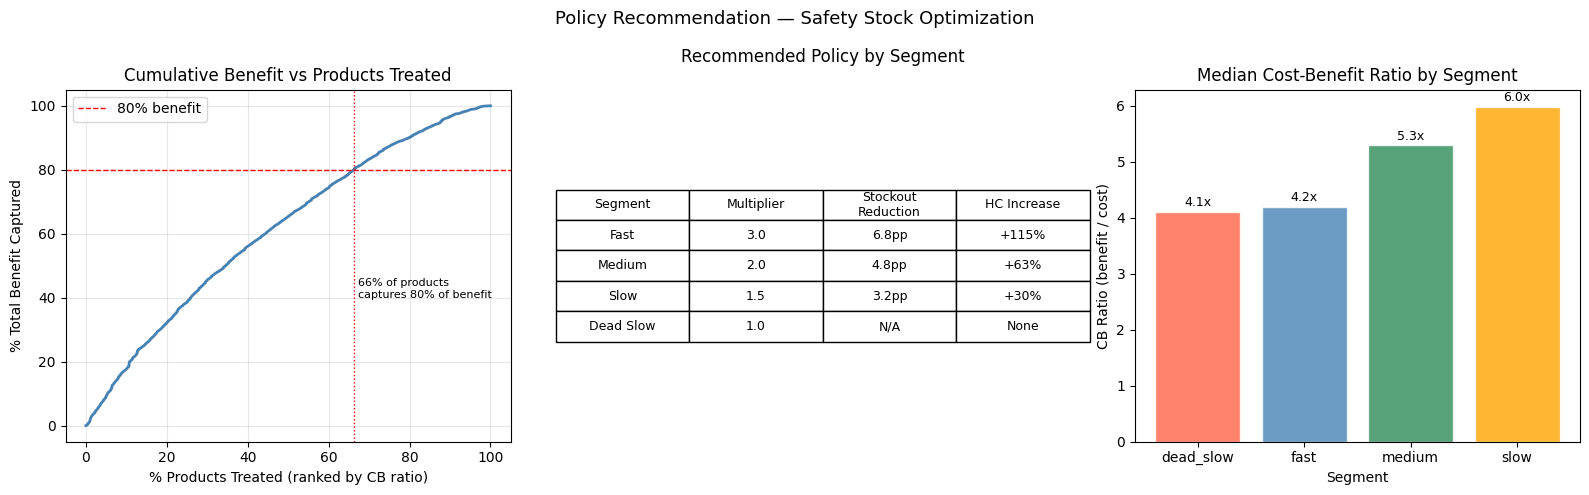

=== BUDGET SCENARIO ===

If we treat top 20% of products by CB ratio:
  Products treated: 1,133
  Benefit captured: 32.1% of total
  Daily HC increase: $32.32

If we treat top 50% of products by CB ratio:
  Products treated: 2,833
  Benefit captured: 65.4% of total
  Daily HC increase: $88.14

Full catalog treatment:
  Products treated: 5,667
  Total benefit: $943388.00
  Daily HC increase: $211.47


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cumulative benefit curve
total_products = len(product_cb)
pct_products = np.arange(1, total_products+1) / total_products * 100
total_benefit = product_cb['stockout_cost_saved'].sum()

axes[0].plot(pct_products, 
             product_cb['cumulative_benefit'] / total_benefit * 100,
             color='steelblue', linewidth=2)
axes[0].axhline(80, color='red', linestyle='--', linewidth=1, label='80% benefit')
idx_80 = np.argmax(product_cb['cumulative_benefit'] >= total_benefit * 0.8)
axes[0].axvline(pct_products[idx_80], color='red', linestyle=':', linewidth=1)
axes[0].set_title('Cumulative Benefit vs Products Treated')
axes[0].set_xlabel('% Products Treated (ranked by CB ratio)')
axes[0].set_ylabel('% Total Benefit Captured')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].text(pct_products[idx_80]+1, 40, 
             f'{pct_products[idx_80]:.0f}% of products\ncaptures 80% of benefit',
             fontsize=8)

# Recommended policy by segment
seg_rec = pd.DataFrame({
    'Segment':    ['Fast', 'Medium', 'Slow', 'Dead Slow'],
    'Multiplier': [3.0, 2.0, 1.5, 1.0],
    'Stockout\nReduction': ['6.8pp', '4.8pp', '3.2pp', 'N/A'],
    'HC Increase': ['+115%', '+63%', '+30%', 'None']
})

axes[1].axis('off')
table = axes[1].table(
    cellText=seg_rec.values,
    colLabels=seg_rec.columns,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.0)
axes[1].set_title('Recommended Policy by Segment', pad=20)

# CB ratio by segment
seg_cb_ratio = product_cb.groupby('segment', observed=True)['cb_ratio'].median()
colors = ['tomato', 'steelblue', 'seagreen', 'orange']
axes[2].bar(seg_cb_ratio.index, seg_cb_ratio.values,
            color=colors, alpha=0.8, edgecolor='white')
axes[2].set_title('Median Cost-Benefit Ratio by Segment')
axes[2].set_xlabel('Segment')
axes[2].set_ylabel('CB Ratio (benefit / cost)')
for i, v in enumerate(seg_cb_ratio.values):
    axes[2].text(i, v + 0.1, f'{v:.1f}x', ha='center', fontsize=9)

plt.suptitle('Policy Recommendation — Safety Stock Optimization', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_PATH / '06_policy_recommendation.png', dpi=150)
plt.show()

# Budget scenario
print("=== BUDGET SCENARIO ===")
print(f"\nIf we treat top 20% of products by CB ratio:")
top20_idx = int(len(product_cb) * 0.2)
top20 = product_cb.iloc[:top20_idx]
print(f"  Products treated: {top20_idx:,}")
print(f"  Benefit captured: {top20['stockout_cost_saved'].sum()/total_benefit*100:.1f}% of total")
print(f"  Daily HC increase: ${top20['hc_increase_daily'].sum():.2f}")

print(f"\nIf we treat top 50% of products by CB ratio:")
top50_idx = int(len(product_cb) * 0.5)
top50 = product_cb.iloc[:top50_idx]
print(f"  Products treated: {top50_idx:,}")
print(f"  Benefit captured: {top50['stockout_cost_saved'].sum()/total_benefit*100:.1f}% of total")
print(f"  Daily HC increase: ${top50['hc_increase_daily'].sum():.2f}")

print(f"\nFull catalog treatment:")
print(f"  Products treated: {len(product_cb):,}")
print(f"  Total benefit: ${total_benefit:.2f}")
print(f"  Daily HC increase: ${product_cb['hc_increase_daily'].sum():.2f}")

## Policy Recommendations

### Recommended Safety Stock Policy by Segment

| Segment | Current Multiplier | Recommended | Stockout Reduction | HC Increase | CB Ratio |
|---|---|---|---|---|---|
| Fast (>10 units/day) | 1.0x | 3.0x | 6.8pp | +115% | 4.2x |
| Medium (2-10 units/day) | 1.0x | 2.0x | 4.8pp | +63% | 5.3x |
| Slow (0.5-2 units/day) | 1.0x | 1.5x | 3.2pp | +30% | 6.0x |
| Dead slow (<0.5 units/day) | 1.0x | No change | N/A | None | N/A |

### Budget-Constrained Rollout
If budget is limited, prioritize by cost-benefit ratio:
- **Top 20% of products** → captures 32% of total benefit at $32/day HC increase
- **Top 50% of products** → captures 65% of total benefit at $88/day HC increase
- **Full catalog** → captures 100% of benefit at $211/day HC increase

66% of products ranked by CB ratio capture 80% of total benefit.

### Key Findings
1. Slow movers have the best CB ratio (6.0x) — modest cost, meaningful benefit
2. Fast movers have the highest absolute benefit but also highest cost
3. Dead slow products should not receive additional safety stock
4. A targeted policy by segment significantly outperforms a blanket policy

### Important Caveat
All benefit estimates assume $5/unit stockout cost (lost margin).
Actual stockout cost varies by product margin and customer lifetime
value impact. Sensitivity analysis on this assumption is recommended
before operational deployment.

### Next Steps for Production
1. Validate stockout cost assumption with finance team
2. Add warehouse space constraints — not modeled here
3. Extend to TX and WI stores to test generalizability
4. Run live A/B test on a subset of stores to validate simulation findings